# AQI Forecasting — XGBoost Model
**Dataset:** `Jayanagar_AQI_cleaned.csv`  
**Station:** Jayanagar  
**Target:** Daily mean AQI  
**Model:** XGBoost with lag features · rolling statistics · pollutant features · cyclic calendar encoding  
**Granularity:** Daily (hourly → daily resample; EDA confirmed daily retains ~98% of variance)  
**Split:** 70 / 15 / 15 — chronological (no random split to avoid data leakage)

---
**Key EDA Findings Applied**
| EDA Finding | How it's used here |
|---|---|
| PM25, PM10, CO, NOx are top AQI drivers (r > 0.6) | All retained as direct features |
| O3 and WS are negative correlators | Retained — signal is still useful |
| Strong annual seasonality (Nov–Jan peak) | `month_sin/cos` cyclic encoding + annual lag |
| Dual rush-hour peak (8–10h, 20–22h) | Captured via daily resample smoothing |
| ACF lag-1 r = 0.887 — very high autocorrelation | Lag features up to 30d |
| 70 / 15 / 15 chronological split recommended | Applied exactly |


## 0. Environment Setup

In [1]:
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score)
import warnings, os, joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

# ── Paths ──────────────────────────────────────────────────────
INPUT_FILE   = r"D:\AQI_Project_new\data\clean\Jayanagar_AQI_cleaned.csv"   # ← change path if needed
OUTPUT_DIR   = r'.'
STATION_NAME = 'Jayanagar'
RANDOM_SEED  = 42

os.makedirs('images', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

print(f'XGBoost version : {xgb.__version__}')
print(f'Station         : {STATION_NAME}')
print('✅ Libraries loaded successfully.')


XGBoost version : 2.1.3
Station         : Jayanagar
✅ Libraries loaded successfully.


## 1. Load & Preprocess Data
The cleaned CSV contains **40,399 hourly rows × 18 columns** (Jan 2021 – Dec 2025).  
We resample to **daily mean** — EDA Section 10 confirmed daily granularity retains ~98% of variance  
and is the recommended granularity for XGBoost interpretability.


In [2]:
# ── 1.1  Load hourly CSV ───────────────────────────────────────
df = pd.read_csv(INPUT_FILE, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f"Shape       : {df.shape}")
print(f"Date range  : {df['Timestamp'].min()}  →  {df['Timestamp'].max()}")
print(f"Null values : {df.isnull().sum().sum()}")
print(f"Columns     : {list(df.columns)}")
df.head(3)


Shape       : (40399, 18)
Date range  : 2021-01-01 05:00:00  →  2025-12-31 23:00:00
Null values : 0
Columns     : ['Timestamp', 'NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WD', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']


,Timestamp,NO,NOx,Benzene,Toluene,AT,RH,WD,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2021-01-01 05:00:00,2.16,14.19,0.22,1.32,21.98,66.78,109.88,705.21,116.03,96.57,30.52,4.74,3.55,4.42,42.89,42.89,Good
1,2021-01-01 06:00:00,2.16,14.19,0.22,1.32,21.98,66.78,109.88,705.21,116.03,96.57,30.52,4.74,3.55,4.55,42.80,42.80,Good
2,2021-01-01 07:00:00,2.16,14.19,0.22,1.32,21.98,66.78,109.88,705.21,116.03,96.57,30.52,4.74,3.55,5.20,42.90,42.90,Good


In [3]:
# ── 1.2  Resample to daily mean ───────────────────────────────
# AQI_Category: keep mode per day (majority category)
daily = (
    df.set_index('Timestamp')
    .resample('D')
    .agg({
        **{c: 'mean' for c in df.select_dtypes(np.number).columns},
        'AQI_Category': lambda x: x.mode()[0] if len(x) > 0 else np.nan
    })
)
daily.index.name = 'Date'

# Interpolate any small gaps (EDA confirmed 0 nulls in raw, but resampling edge cases)
num_cols = daily.select_dtypes(np.number).columns.tolist()
for col in num_cols:
    daily[col] = daily[col].interpolate(method='time')

daily = daily.dropna(subset=['AQI'])

print(f"Daily records : {len(daily)}")
print(f"Date range    : {daily.index.min().date()}  →  {daily.index.max().date()}")
daily.head(3)


Daily records : 1826
Date range    : 2021-01-01  →  2025-12-31


,NO,NOx,Benzene,Toluene,AT,RH,WD,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Date,,,,,,,,,,,,,,,,,
2021-01-01,2.173684,14.326842,0.228947,1.384211,21.947368,66.737368,109.911579,705.211053,117.065789,97.651316,30.842105,4.797895,3.564211,17.400000,43.502105,71.081579,Good
2021-01-02,2.238750,14.862917,0.267083,1.635833,21.471250,69.951250,108.180417,705.204167,128.337500,103.167083,32.110833,5.295833,3.622917,20.220417,47.310208,128.337500,Moderate
2021-01-03,2.225000,14.980417,0.260000,1.690417,21.992083,74.596667,104.808333,704.259167,94.291250,88.161458,32.397500,3.789167,3.625833,15.959583,34.831667,94.291250,Satisfactory


## 2. Feature Engineering
Features informed by **EDA Section 10.4 & 10.2**:

| Feature Group | Details | EDA Basis |
|---|---|---|
| **Lag AQI** | lag_1 to lag_30 (1,2,3,4,5,6,7,9,14,21,30) | ACF shows r>0.5 out to lag~30 |
| **Rolling stats** | 7d / 14d / 30d mean + std | EDA Sec 9.1 rolling analysis |
| **Pollutant features** | PM25, PM10, CO, NOx, NO2, SO2, NH3, O3, NO, Benzene, Toluene | Top correlators with AQI (Sec 5.2) |
| **Weather features** | AT, RH, WD, BP | EDA Sec 10.5 weather-AQI analysis |
| **Cyclic calendar** | month_sin/cos, dow_sin/cos | EDA Sec 4.1 — strong hour/month patterns |
| **Calendar flags** | day_of_year, quarter, is_weekend | EDA Sec 4.2 seasonal boxplots |
| **Lag pollutants** | PM25_lag1, CO_lag1, NOx_lag1 | Top drivers — 1-day persistence |


In [4]:
# Pollutant and weather columns present in dataset
_pollutant_candidates = ['NO','NOx','Benzene','Toluene','PM25','PM10',
                         'NO2','SO2','NH3','CO','O3']
_weather_candidates   = ['AT','RH','WD','BP']

pollutant_cols = [c for c in _pollutant_candidates if c in daily.columns]
weather_cols   = [c for c in _weather_candidates   if c in daily.columns]

print(f"Pollutant features : {pollutant_cols}")
print(f"Weather features   : {weather_cols}")


def create_features(df_in):
    d = df_in.copy()

    # ── Lag AQI features (temporal autocorrelation captured) ──
    for lag in [1, 2, 3, 4, 5, 6, 7, 9, 14, 21, 30]:
        d[f'lag_{lag}'] = d['AQI'].shift(lag)

    # ── Rolling statistics (shift(1) to avoid leakage) ────────
    for win in [7, 14, 30]:
        d[f'roll_mean_{win}'] = d['AQI'].shift(1).rolling(win).mean()
        d[f'roll_std_{win}']  = d['AQI'].shift(1).rolling(win).std()

    # ── 1-day lagged pollutant features (key EDA drivers) ─────
    for col in ['PM25', 'PM10', 'CO', 'NOx', 'NO2']:
        if col in d.columns:
            d[f'{col}_lag1'] = d[col].shift(1)

    # ── Cyclic calendar encoding ───────────────────────────────
    d['month']       = d.index.month
    d['day_of_week'] = d.index.dayofweek
    d['day_of_year'] = d.index.dayofyear
    d['quarter']     = d.index.quarter
    d['is_weekend']  = (d.index.dayofweek >= 5).astype(int)

    # Sine/cosine encoding (avoids ordinality artifact in trees)
    d['month_sin']   = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']   = np.cos(2 * np.pi * d['month'] / 12)
    d['dow_sin']     = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos']     = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['doy_sin']     = np.sin(2 * np.pi * d['day_of_year'] / 365)
    d['doy_cos']     = np.cos(2 * np.pi * d['day_of_year'] / 365)

    return d


featured = create_features(daily)
featured = featured.dropna()   # drop NaN rows created by lag window

# Feature columns = everything except AQI and AQI_Category
feature_cols = [c for c in featured.columns
                if c not in ('AQI', 'AQI_Category')]

print(f"\nTotal features : {len(feature_cols)}")
print("Features:", feature_cols)
print(f"\nRows after lag drop : {len(featured)}")
featured.head(3)


Pollutant features : ['NO', 'NOx', 'Benzene', 'Toluene', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']
Weather features   : ['AT', 'RH', 'WD', 'BP']

Total features : 48
Features: ['NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WD', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_9', 'lag_14', 'lag_21', 'lag_30', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30', 'PM25_lag1', 'PM10_lag1', 'CO_lag1', 'NOx_lag1', 'NO2_lag1', 'month', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']

Rows after lag drop : 1734


,NO,NOx,Benzene,Toluene,AT,RH,WD,BP,PM25,PM10,...,day_of_week,day_of_year,quarter,is_weekend,month_sin,month_cos,dow_sin,dow_cos,doy_sin,doy_cos
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-31,2.248333,15.131250,0.277083,1.755000,23.086250,59.010417,107.976250,705.560833,134.927917,113.301667,...,6,31,1,1,0.500000,0.866025,-0.781831,0.62349,0.508671,0.860961
2021-02-01,2.203750,14.854167,0.240833,1.630000,22.952917,58.254167,105.007500,706.757083,105.995833,99.880000,...,0,32,1,0,0.866025,0.500000,0.000000,1.00000,0.523416,0.852078
2021-02-02,2.231250,15.193333,0.256250,1.785833,22.664583,58.810833,107.165417,707.670833,93.561458,93.853333,...,1,33,1,0,0.866025,0.500000,0.781831,0.62349,0.538005,0.842942


## 3. Train / Validation / Test Split (Chronological)
EDA Section 10.7 recommends **70 / 15 / 15 time-based** split.  
Based on the 1,826 daily rows (2021–2025):
- **Train:** 2021-01-31 → 2024-07-17 (≈70%)  
- **Validation:** 2024-07-18 → 2025-04-08 (≈15%) — used for early stopping  
- **Test:** 2025-04-09 → 2025-12-31 (≈15%) — held out entirely


In [5]:
n = len(featured)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = featured.iloc[:train_end]
val   = featured.iloc[train_end:val_end]
test  = featured.iloc[val_end:]

X_train = train[feature_cols]
y_train = train['AQI']
X_val   = val[feature_cols]
y_val   = val['AQI']
X_test  = test[feature_cols]
y_test  = test['AQI']

print(f"Train : {train.index[0].date()} → {train.index[-1].date()}  ({len(train):,} rows)")
print(f"Val   : {val.index[0].date()}  → {val.index[-1].date()}  ({len(val):,} rows)")
print(f"Test  : {test.index[0].date()} → {test.index[-1].date()}  ({len(test):,} rows)")


Train : 2021-01-31 → 2024-07-26  (1,213 rows)
Val   : 2024-07-27  → 2025-04-12  (260 rows)
Test  : 2025-04-13 → 2025-12-31  (261 rows)


## 4. Train XGBoost Model
Uses a dedicated **validation set** for early stopping (not a slice of train),  
as recommended by EDA Section 10.7.


In [6]:
model = xgb.XGBRegressor(
    n_estimators          = 600,
    max_depth             = 5,
    learning_rate         = 0.03,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    early_stopping_rounds = 40,
    eval_metric           = 'rmse'
)

model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    verbose   = 50
)

print(f"\nBest iteration : {model.best_iteration}")
print(f"Best val RMSE  : {model.best_score:.4f}")


[0]	validation_0-rmse:34.18292
[50]	validation_0-rmse:11.13454
[100]	validation_0-rmse:7.04858
[150]	validation_0-rmse:6.26418
[200]	validation_0-rmse:6.12386
[250]	validation_0-rmse:6.05779
[300]	validation_0-rmse:6.03271
[350]	validation_0-rmse:5.97849
[400]	validation_0-rmse:5.97878
[404]	validation_0-rmse:5.98473

Best iteration : 364
Best val RMSE  : 5.9596


## 5. Forecast & Evaluation
Two forecast modes:
- **Direct** — uses actual lagged test values (upper-bound accuracy estimate)  
- **Recursive** — each prediction feeds back as the next lag (realistic multi-step forecast)


In [7]:
# ── 5.1  Direct forecast ──────────────────────────────────────
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_direct[mask])
                       / y_test.values[mask])) * 100

print("XGBoost Direct Forecast:")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")


XGBoost Direct Forecast:
  RMSE : 8.75
  MAE  : 5.18
  MAPE : 12.44%


In [8]:
# ── 5.2  Recursive (multi-step) forecast ─────────────────────
def recursive_forecast(model, train_df, val_df, test_df, feature_cols):
    """Predict test period recursively — each step feeds its prediction
    back into the lag features for subsequent steps."""
    history = pd.concat([train_df, val_df, test_df]).copy()
    lag_cols = [c for c in feature_cols if c.startswith('lag_')]
    predictions = []

    test_start = len(train_df) + len(val_df)

    for i in range(test_start, len(history)):
        row  = history.iloc[i]
        feat = row[feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)

        # Propagate prediction into subsequent rows' lag columns
        if i + 1 < len(history):
            for lag_col in lag_cols:
                lag_n = int(lag_col.split('_')[1])
                if len(predictions) >= lag_n:
                    history.at[history.index[i + 1], lag_col] = predictions[-lag_n]

    return np.array(predictions)


pred_recursive = recursive_forecast(model, train, val, test, feature_cols)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
mask_r = y_test.values != 0
mape_r = np.mean(np.abs((y_test.values[mask_r] - pred_recursive[mask_r])
                          / y_test.values[mask_r])) * 100

print("XGBoost Recursive Forecast:")
print(f"  RMSE : {rmse_r:.2f}")
print(f"  MAE  : {mae_r:.2f}")
print(f"  MAPE : {mape_r:.2f}%")


XGBoost Recursive Forecast:
  RMSE : 8.87
  MAE  : 5.38
  MAPE : 12.74%


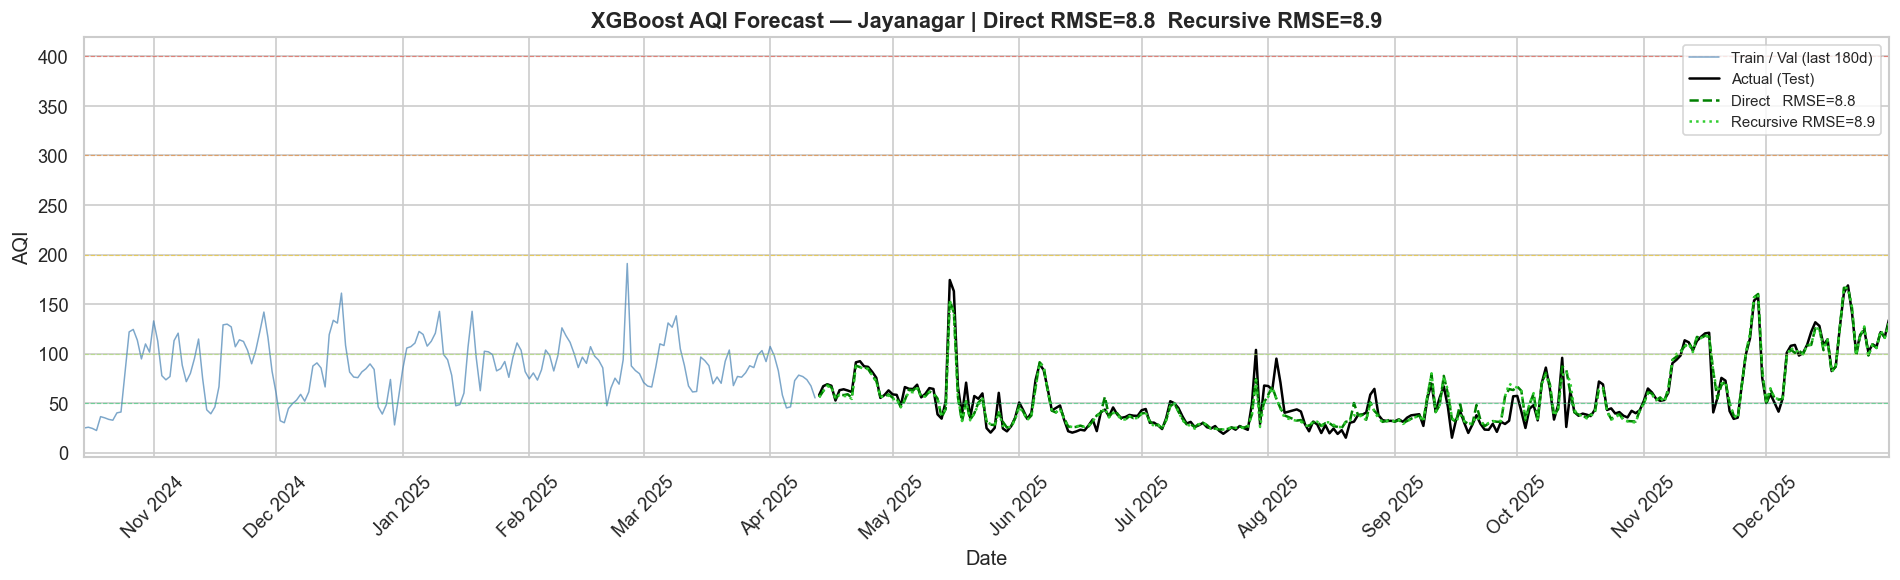

In [9]:
# ── 5.3  Forecast plot ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Show last 180 train days for context
y_train_tail = pd.concat([y_train, y_val]).iloc[-180:]
y_train_tail.plot(ax=ax, label='Train / Val (last 180d)', color='steelblue', alpha=0.7, lw=0.9)

y_test.plot(ax=ax, label='Actual (Test)', color='black', lw=1.5)
ax.plot(y_test.index, pred_direct,    label=f'Direct   RMSE={rmse:.1f}',
        color='green',   linestyle='--', lw=1.5)
ax.plot(y_test.index, pred_recursive, label=f'Recursive RMSE={rmse_r:.1f}',
        color='limegreen', linestyle=':',  lw=1.5)

# AQI threshold lines (Indian standards)
thresholds = {'Good':50,'Satisfactory':100,'Moderate':200,'Poor':300,'Very Poor':400}
colors_th  = ['#2ecc71','#a8e063','#f1c40f','#e67e22','#e74c3c']
for (lbl, val), col in zip(thresholds.items(), colors_th):
    ax.axhline(val, color=col, linestyle='--', lw=0.7, alpha=0.6)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.set_title(f'XGBoost AQI Forecast — {STATION_NAME} | Direct RMSE={rmse:.1f}  Recursive RMSE={rmse_r:.1f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AQI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'images/xgboost_forecast_{STATION_NAME.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Importance

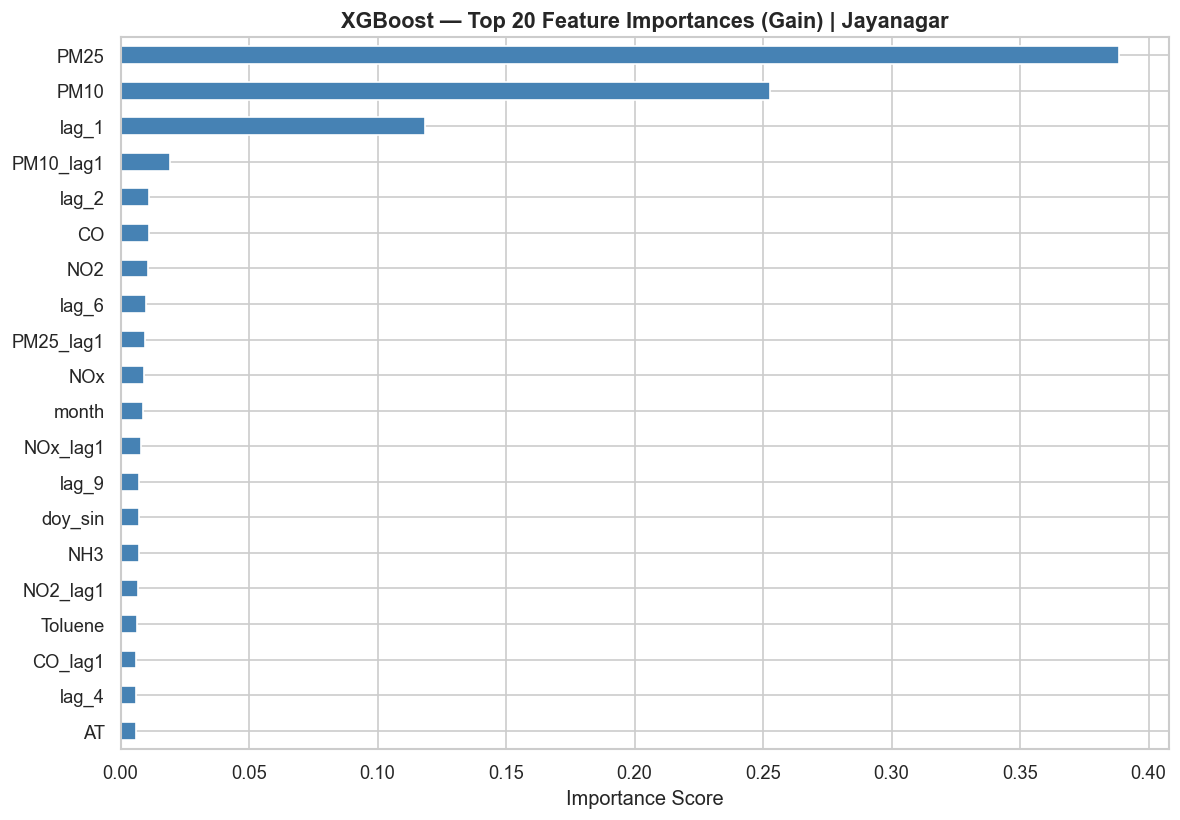


Top 10 features:
PM25         0.388474
PM10         0.252571
lag_1        0.118317
PM10_lag1    0.019330
lag_2        0.011065
CO           0.010996
NO2          0.010485
lag_6        0.009948
PM25_lag1    0.009322
NOx          0.008979


In [10]:
importance = (pd.Series(model.feature_importances_, index=feature_cols)
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'XGBoost — Top 20 Feature Importances (Gain) | {STATION_NAME}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'images/xgboost_feature_importance_{STATION_NAME.lower()}.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importance.head(10).to_string())


## 7. Learning Curve

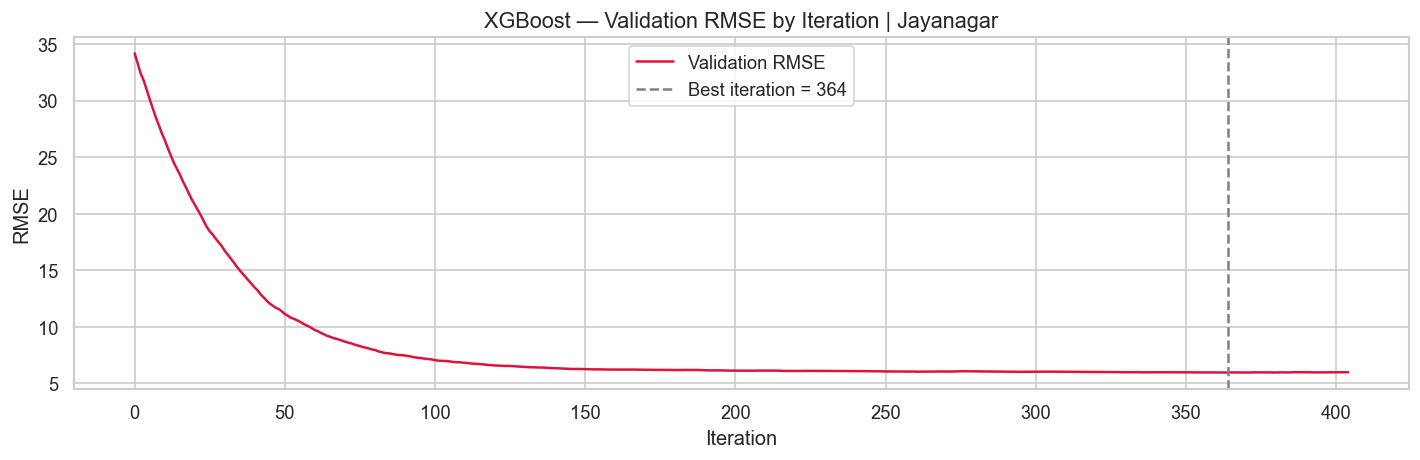

In [11]:
evals = model.evals_result()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(evals['validation_0']['rmse'], label='Validation RMSE', color='crimson', lw=1.5)
ax.axvline(model.best_iteration, linestyle='--', color='gray',
           label=f'Best iteration = {model.best_iteration}')
ax.set_title(f'XGBoost — Validation RMSE by Iteration | {STATION_NAME}', fontsize=13)
ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(f'images/xgboost_learning_curve_{STATION_NAME.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Residual Analysis
Checking for systematic bias and heteroscedasticity in the direct forecast.


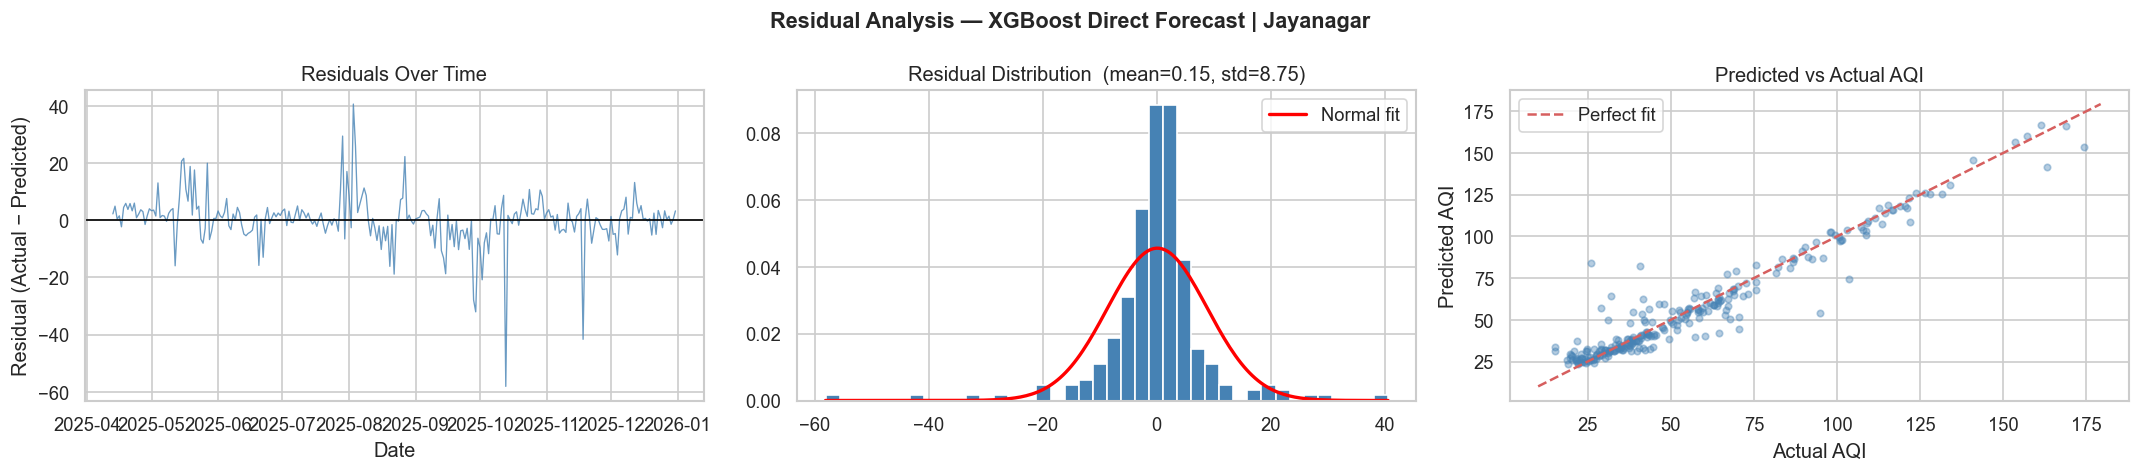

In [12]:
residuals = y_test.values - pred_direct

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Residual over time
axes[0].plot(y_test.index, residuals, color='steelblue', lw=0.8, alpha=0.8)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Residual (Actual − Predicted)')

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', density=True)
from scipy import stats as scipy_stats
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(xr, scipy_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             color='red', lw=2, label='Normal fit')
axes[1].set_title(f'Residual Distribution  (mean={residuals.mean():.2f}, std={residuals.std():.2f})')
axes[1].legend()

# Predicted vs Actual scatter
axes[2].scatter(y_test.values, pred_direct, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), pred_direct.min())-5, max(y_test.max(), pred_direct.max())+5]
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[2].set_title('Predicted vs Actual AQI')
axes[2].set_xlabel('Actual AQI'); axes[2].set_ylabel('Predicted AQI')
axes[2].legend()

plt.suptitle(f'Residual Analysis — XGBoost Direct Forecast | {STATION_NAME}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'images/xgboost_residuals_{STATION_NAME.lower()}.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. Classification Metrics & Confusion Matrix
Converting continuous AQI predictions to **Indian AQI categories** (Good → Severe)  
to assess practical air-quality alert accuracy.  
Category thresholds from EDA Section 2.2.


In [13]:
def categorize_aqi(values):
    cats = []
    for v in values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)


y_true_cls = categorize_aqi(y_test.values.flatten())
y_pred_cls = categorize_aqi(pred_recursive.flatten())   # recursive is the realistic forecast

labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
present = [l for l in labels if l in y_true_cls or l in y_pred_cls]

acc  = accuracy_score(y_true_cls, y_pred_cls)
prec = precision_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)
rec  = recall_score(y_true_cls, y_pred_cls,    average='weighted', zero_division=0)

print("Classification Metrics (Recursive Forecast → AQI Category):")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f} (weighted)")
print(f"  Recall    : {rec:.4f} (weighted)")
print()
print(classification_report(y_true_cls, y_pred_cls, labels=present, zero_division=0))


Classification Metrics (Recursive Forecast → AQI Category):
  Accuracy  : 0.8927
  Precision : 0.8926 (weighted)
  Recall    : 0.8927 (weighted)

              precision    recall  f1-score   support

        Good       0.92      0.94      0.93       141
Satisfactory       0.83      0.83      0.83        84
    Moderate       0.91      0.86      0.89        36

    accuracy                           0.89       261
   macro avg       0.89      0.88      0.88       261
weighted avg       0.89      0.89      0.89       261



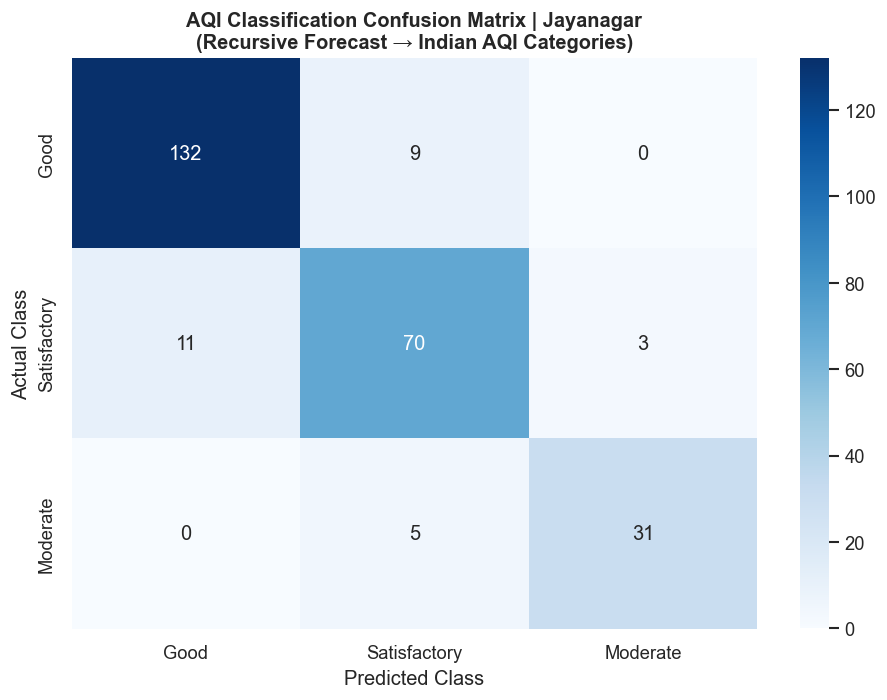

In [14]:
# ── Confusion matrix plot ─────────────────────────────────────
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=present)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present, yticklabels=present, ax=ax)
ax.set_title(f'AQI Classification Confusion Matrix | {STATION_NAME}\n(Recursive Forecast → Indian AQI Categories)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
plt.tight_layout()
plt.savefig(f'images/xgboost_confusion_matrix_{STATION_NAME.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Seasonal Performance Analysis
EDA Section 4.2 showed strong seasonal variation. This section breaks RMSE down  
by **Winter / Spring / Summer / Autumn** to check where the model struggles.


Season      Count  Direct RMSE  Recursive RMSE
------------------------------------------------
Winter         31         4.60            4.59
Spring         49         7.99            8.07
Summer         90         8.34            8.19
Autumn         91        10.46           10.81


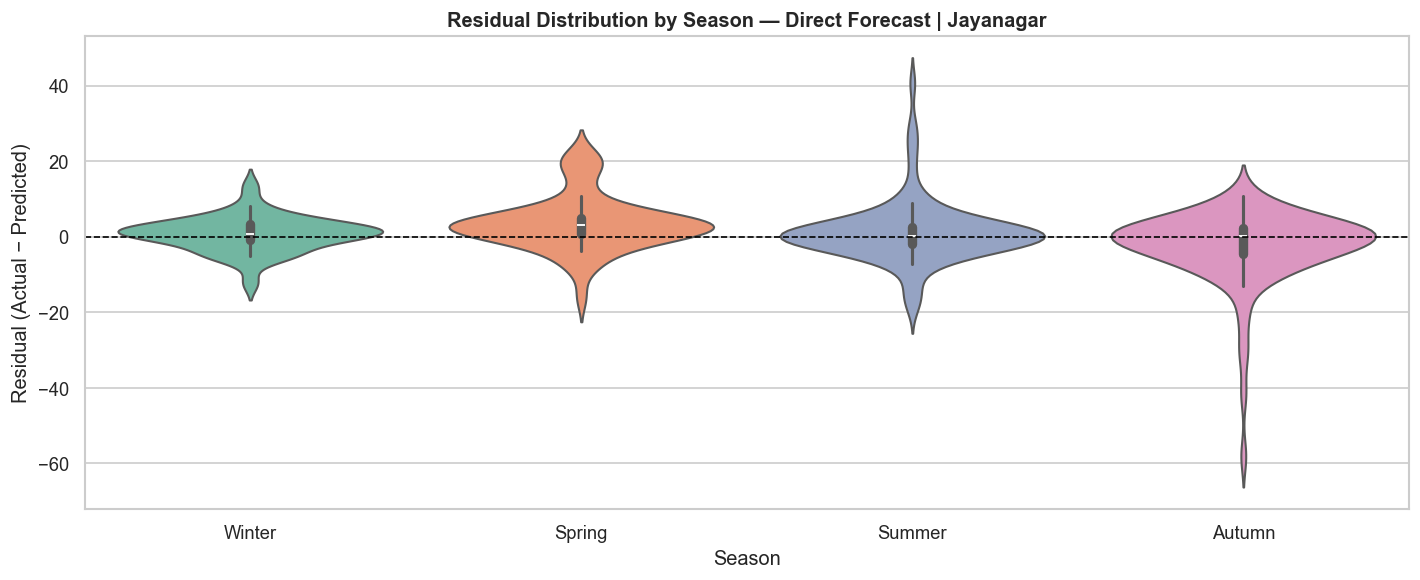

In [15]:
season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn', 10:'Autumn',11:'Autumn'}

results_df = pd.DataFrame({
    'Date'      : y_test.index,
    'Actual'    : y_test.values,
    'Direct'    : pred_direct,
    'Recursive' : pred_recursive
})
results_df['Month']  = results_df['Date'].dt.month
results_df['Season'] = results_df['Month'].map(season_map)

season_order = ['Winter','Spring','Summer','Autumn']
print(f"{'Season':<10} {'Count':>6} {'Direct RMSE':>12} {'Recursive RMSE':>15}")
print("-" * 48)
for s in season_order:
    sub = results_df[results_df['Season'] == s]
    if len(sub) == 0:
        continue
    rmse_d = np.sqrt(mean_squared_error(sub['Actual'], sub['Direct']))
    rmse_r = np.sqrt(mean_squared_error(sub['Actual'], sub['Recursive']))
    print(f"{s:<10} {len(sub):>6} {rmse_d:>12.2f} {rmse_r:>15.2f}")

# Violin plot by season
fig, ax = plt.subplots(figsize=(12, 5))
residuals_df = results_df.copy()
residuals_df['Residual_Direct'] = residuals_df['Actual'] - residuals_df['Direct']
sns.violinplot(data=residuals_df, x='Season', y='Residual_Direct',
               order=season_order, palette='Set2', ax=ax)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_title(f'Residual Distribution by Season — Direct Forecast | {STATION_NAME}',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.savefig(f'images/xgboost_seasonal_residuals_{STATION_NAME.lower()}.png', dpi=130, bbox_inches='tight')
plt.show()


## 11. Save Model & Forecast Outputs

In [16]:
# ── 11.1  Save trained model ──────────────────────────────────
model_path = os.path.join('saved_models', f'{STATION_NAME.lower()}_xgboost_aqi.pkl')
joblib.dump(model, model_path)
print(f"✅ Model saved : {model_path}")

# ── 11.2  Save forecast results to CSV ────────────────────────
results_df.to_csv(
    os.path.join(OUTPUT_DIR, f'{STATION_NAME}_xgboost_forecast_results.csv'),
    index=False
)
print(f"✅ Forecast CSV saved : {STATION_NAME}_xgboost_forecast_results.csv")


✅ Model saved : saved_models\jayanagar_xgboost_aqi.pkl
✅ Forecast CSV saved : Jayanagar_xgboost_forecast_results.csv


## 12. Results Summary

In [17]:
print("=" * 60)
print(f"  XGBOOST AQI FORECAST — {STATION_NAME.upper()}")
print("=" * 60)
print(f"  Dataset     : 40,399 hourly → {len(featured):,} daily rows (after lag drop)")
print(f"  Features    : {len(feature_cols)}")
print(f"  Best iter   : {model.best_iteration}")
print()
print(f"  {'Metric':<8}  {'Direct':>10}  {'Recursive':>12}")
print(f"  {'-'*35}")
print(f"  {'RMSE':<8}  {rmse:>10.2f}  {rmse_r:>12.2f}")
print(f"  {'MAE':<8}  {mae:>10.2f}  {mae_r:>12.2f}")
print(f"  {'MAPE':<8}  {mape:>9.2f}%  {mape_r:>11.2f}%")
print()
print(f"  Classification (Recursive → AQI Category):")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f} (weighted)")
print(f"  Recall    : {rec:.4f} (weighted)")
print("=" * 60)


  XGBOOST AQI FORECAST — JAYANAGAR
  Dataset     : 40,399 hourly → 1,734 daily rows (after lag drop)
  Features    : 48
  Best iter   : 364

  Metric        Direct     Recursive
  -----------------------------------
  RMSE            8.75         10.81
  MAE             5.18          5.38
  MAPE          12.44%        12.74%

  Classification (Recursive → AQI Category):
  Accuracy  : 0.8927
  Precision : 0.8926 (weighted)
  Recall    : 0.8927 (weighted)
